# [RSNA 2023 Abdominal Trauma Detection](https://www.kaggle.com/competitions/rsna-2023-abdominal-trauma-detection)

> Detect and classify traumatic abdominal injuries

![](https://www.kaggle.com/competitions/52254/images/header)

# 🧪 Experiment 5: (ATD_ResNet50_CutMixUp_Model)
* **ATD**= `Abdominal Trauma Detection`.
* **Simple** = Here it refer to experiment we will be conducting **without using any kind of data augmentation**.

### **CutMix: A Powerful Data Augmentation Technique**

**[CutMix](https://arxiv.org/abs/1905.04899)** is a data augmentation method that injects artificial samples into your training dataset by combining two images and their labels in a new way. This helps improve model robustness and generalization, especially for tasks like object detection and classification.

🔑 Key Idea:

1. **Random Image Selection:** CutMix randomly selects two images (x1, y1) and (x2, y2) from your dataset, along with their corresponding ground-truth labels (y1 and y2).

2. **Cut and Paste:** It randomly cuts out a rectangular region (region_1) from one image (x1) and pastes it onto the other image (x2) at a randomly chosen location (region_2).

3. **Label Mixing:** The labels are mixed based on the area proportions of the two regions:

`New label (y) = λ * y1 + (1 - λ) * y2`
> where λ (lambda) is a randomly sampled beta distribution parameter (β) between 0 and 1, controlling the influence of each original label.

🔑 **Benefits**

* **Improved Generalization**.
* **Increased Localization Ability**.

## Step 1: Downloading And Extracting Data From Kaggle
🔑 **Note**: You will need your personal kaggle api key as kaggle.json that you can get on kaggle.

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d jayantarsode/rsna-abdominal-trauma-subset

100% 6.53G/6.54G [03:37<00:00, 39.2MB/s]
100% 6.54G/6.54G [03:37<00:00, 32.2MB/s]


In [ ]:
!unzip /content/rsna-abdominal-trauma-subset.zip

Streaming output truncated to the last 5000 lines.
  inflating: train_images/38150/25352/254.png  
  inflating: train_images/38150/25352/258.png  
  inflating: train_images/38150/25352/267.png  
  inflating: train_images/38150/25352/268.png  
  inflating: train_images/38150/25352/270.png  
  inflating: train_images/38150/25352/274.png  
  inflating: train_images/38150/25352/276.png  
  inflating: train_images/38150/25352/279.png  
  inflating: train_images/38150/25352/284.png  
  inflating: train_images/38150/25352/286.png  
  inflating: train_images/38150/25352/289.png  
  inflating: train_images/38150/25352/293.png  
  inflating: train_images/38150/25352/294.png  
  inflating: train_images/38150/25352/299.png  
  inflating: train_images/38150/25352/303.png  
  inflating: train_images/38150/25352/306.png  
  inflating: train_images/38150/25352/309.png  
  inflating: train_images/38150/25352/311.png  
  inflating: train_images/38150/25352/318.png  
  inflating: train_images/38150/25352

## Step 2: Installing Important Libraries

In [ ]:
!pip install torchmetrics
!pip install wandb onnx -Uq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.5/841.5 kB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 63.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 65.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 95.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 27.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 14.4 MB/s eta 0:00:00
     ━━━━━━━━━━━

## Step 3: Setting Up Device We Will Work In.

In [ ]:
import torch
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# Device configuration
if device=="cuda":
  !nvidia-smi
else:
  !cat /proc/cpuinfo

Mon Apr  1 04:27:59 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-SXM2-16GB           Off | 00000000:00:04.0 Off |                    0 |
| N/A   36C    P0              24W / 300W |      2MiB / 16384MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

## Step 4: Importing and Using Our Custom Module [torch_helper_functions](https://drive.google.com/drive/folders/11e2iSHGQ9d-DeONfYe7nyY1v09IC1lFh?usp=sharing)

In [ ]:
# Importing custom module
!unzip /content/torch_helper_functions_V1.zip

Archive:  /content/torch_helper_functions_V1.zip
  inflating: torch_helper_functions/plotting_utils.py  
  inflating: torch_helper_functions/multilabel/data_setup.py  
  inflating: torch_helper_functions/multilabel/train_engine.py  
  inflating: torch_helper_functions/utils.py  
  inflating: torch_helper_functions/multilabel/data_cleaner.py  


## Step 5: Importing the patients_with_abnormalities.csv that we got During [data cleaning and analysis](https://colab.research.google.com/drive/1RZLF4R20jLazr9NH_R4Yv6RIw7gZiB4e?usp=sharing).

In [ ]:
# Importing train_valid_images.csv
import pandas as pd
patients_with_abnormalities=pd.read_csv('/content/patients_with_abnormalities.csv').drop(columns=['Unnamed: 0'])
patients_with_abnormalities.head()

,image_path,bowel_healthy,bowel_injury,extravasation_healthy,extravasation_injury,kidney_healthy,kidney_low,kidney_high,liver_healthy,liver_low,liver_high,spleen_healthy,spleen_low,spleen_high
0,/content/train_images/32982/5503/1000.png,1,0,1,0,1,0,0,1,0,0,0,1,0
1,/content/train_images/32982/5503/1001.png,1,0,1,0,1,0,0,1,0,0,0,1,0
2,/content/train_images/32982/5503/1002.png,1,0,1,0,1,0,0,1,0,0,0,1,0
3,/content/train_images/32982/5503/1003.png,1,0,1,0,1,0,0,1,0,0,0,1,0
4,/content/train_images/32982/5503/1004.png,1,0,1,0,1,0,0,1,0,0,0,1,0


## Step 6: Setting Up Dataloaders for Training,Validation and Testing

In [ ]:
# Importing important libraries for handling warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Label Columns to Select
label_columns = [ 'bowel_injury',
                  'extravasation_injury',
                  'kidney_healthy', 'kidney_low','kidney_high',
                  'liver_healthy', 'liver_low', 'liver_high',
                  'spleen_healthy', 'spleen_low', 'spleen_high']

In [ ]:
from torch_helper_functions.multilabel import data_setup
from torchvision.transforms import v2
IMAGE_SIZE= 256
BATCH_SIZE = 32

# Creating a simple transform which resize image and convert it into tensor
custom_transform = v2.Compose([
    v2.Resize(size=(IMAGE_SIZE, IMAGE_SIZE), interpolation=3),  # Resize to desired size
    v2.RandomAffine(degrees=(-5, 5), translate=(0.02, 0.02), scale=(0.95, 1.05), shear=(-2, 2)),  # Adjust for medical images (reduced ranges)
    v2.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05, hue=0.05),  # Adjust for medical images (lower values)
    v2.RandomApply([
        v2.GaussianBlur(kernel_size=(3, 3), sigma=(0.05, 0.2))  # Adjust for medical images (lower sigma range)
    ], p=0.1),
    v2.RandomErasing(p=0.05, scale=(0.02, 0.04), ratio=(0.3, 3.3), value=0),  # Random grayscale after elastic transform (optional)
    v2.RandomGrayscale(p=0.05),
    v2.RandomApply([
        v2.ElasticTransform(alpha=0.1, sigma=0.05),  # Adjust for medical images (lower alpha and sigma)
    ], p=0.2),  # Apply with 20% probability
    v2.ToTensor()
])

val_transform = v2.Compose([
    v2.Resize(size=(IMAGE_SIZE, IMAGE_SIZE), interpolation=3),
    v2.ToTensor()
])

test_transform = v2.Compose([
    v2.Resize(size=(IMAGE_SIZE, IMAGE_SIZE), interpolation=3),
    v2.ToTensor()
])

# Loading the dataloader train,validation and test
train_dataloader, val_dataloader, test_dataloader, classes = data_setup.create_dataloaders_from_dataframe(patients_with_abnormalities,
                                                                                                         'image_path',
                                                                                                         label_columns,
                                                                                                         train_transform=custom_transform,
                                                                                                         val_transform=val_transform,
                                                                                                         test_transform=test_transform,
                                                                                                         batch_size=BATCH_SIZE,
                                                                                                         validation_split=0.15,
                                                                                                         test_split=0.15,
                                                                                                         channels=3)

Each 1 instance in dataloader=32 data points.
Train DataLoader contains: 1918 instance = 61353 data points.
Validation DataLoader contains: 339 instance = 10827 data points.
Test DataLoader contains: 399 instance = 12738 data points.


In [ ]:
print(f"The labels in dataset are: \n{','.join(classes)}")

The labels in dataset are: 
bowel_injury,extravasation_injury,kidney_healthy,kidney_low,kidney_high,liver_healthy,liver_low,liver_high,spleen_healthy,spleen_low,spleen_high


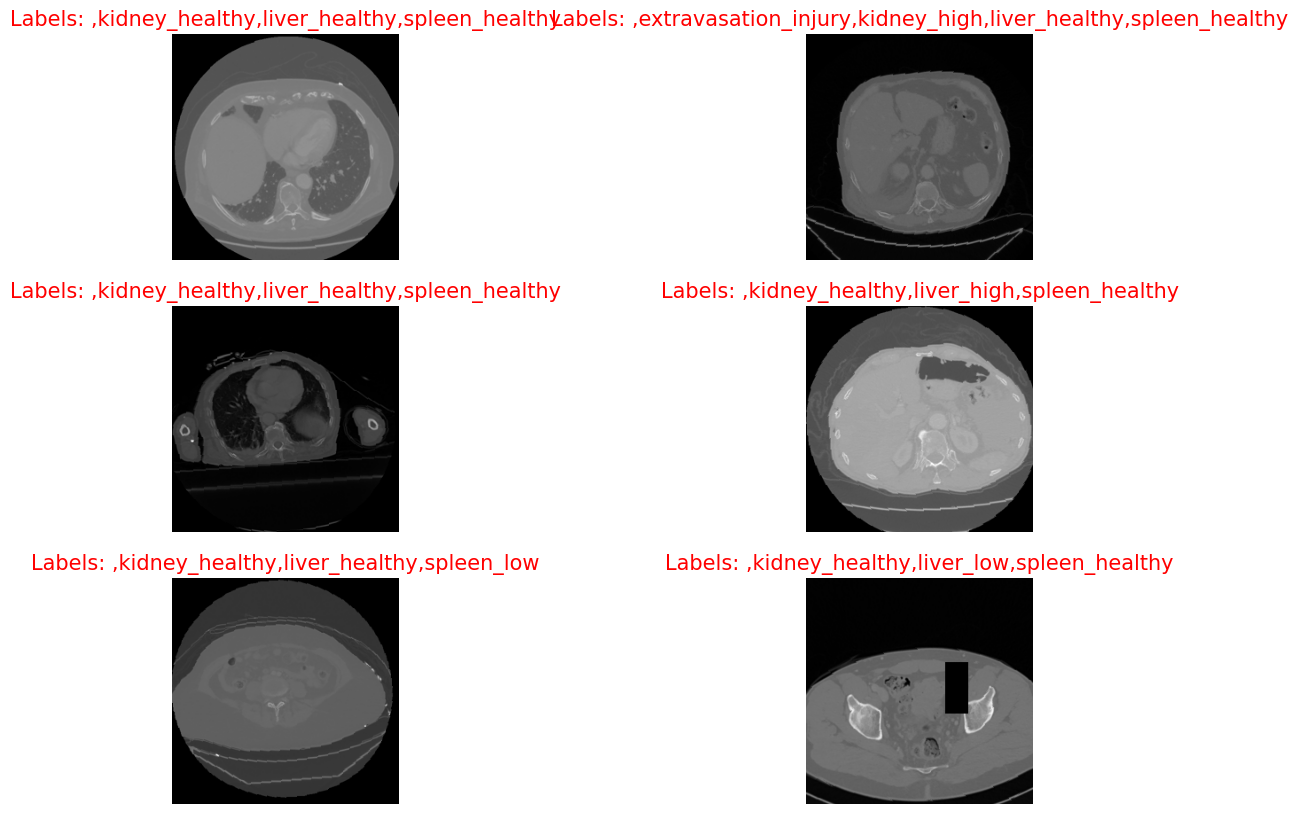

In [ ]:
import random
import matplotlib.pyplot as plt
# Visualizing labels and images
images,y_bowel, y_extra, y_kidney, y_liver, y_spleen = next(iter(train_dataloader))
# Display sample data and labels
fig,ax = plt.subplots(3,2,figsize=(15,10))
ax = ax.ravel()
for k in range(6):
  label=''
  i = random.choice(range(0,31))
  ax[k].imshow(images[i].permute(1,2,0))
  if y_bowel[i].item()==1:
    label+=","+label_columns[0]
  if y_extra[i].item()==1:
    label+=","+label_columns[1]
  label+=","+label_columns[2+y_kidney[i].argmax()]
  label+=","+label_columns[5+y_liver[i].argmax()]
  label+=","+label_columns[8+y_spleen[i].argmax()]
  ax[k].set_title(f"Labels: {label}",c="r",fontsize=15)
  ax[k].axis("off")

## Step 7: Creating Our Model Architecture


In [ ]:
!pip install efficientnet_pytorch

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16429 sha256=eb37fd88bf5593b8ec3d2e75684b5c7d026ae5108dba8f68182dba2caae5a412
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
Successfully built efficientnet_pytorch


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

class ATD_ResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet_base = models.resnet50(pretrained=True)
        # Freeze all parameters of ResNet if pretrained is True
        for param in self.resnet_base.parameters():
            param.requires_grad = False

        # Unfreeze specific layers of ResNet for fine-tuning
        for param in self.resnet_base.layer3[-1:].parameters():
          param.requires_grad = True
        # Unfreeze specific layers of ResNet for fine-tuning
        for param in self.resnet_base.layer4[-3:].parameters():
          param.requires_grad = True

        num_features = self.resnet_base.fc.in_features  # Get the number of features from the last layer of ResNet
        self.resnet_base.fc = nn.Identity()  # Remove the original fully connected layer

        self.flatten = nn.Flatten()  # Flatten the output of ResNet
        self.dropout = nn.Dropout(0.3)  # Dropout with a dropout rate of 0.3

        self.bowel_head = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )

        self.extra_head = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )

        self.liver_head = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.SiLU(),
            nn.Linear(64, 3)
        )

        self.kidney_head = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.SiLU(),
            nn.Linear(64, 3)
        )

        self.spleen_head = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.SiLU(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        x = self.resnet_base(x)
        x = self.dropout(self.flatten(x))
        bowel_out = self.bowel_head(x)
        extra_out = self.extra_head(x)
        kidney_out = self.kidney_head(x)
        liver_out = self.liver_head(x)
        spleen_out = self.spleen_head(x)
        return bowel_out, extra_out, kidney_out, liver_out, spleen_out

## Step 8: Instantiate Model And Getting Model Summary

In [ ]:
# Install torchinfo, import if it's availabel
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

In [ ]:
torch.manual_seed(42)
INPUT_SHAPE=3
ATD_ResNet50_CutMixUp_Model = ATD_ResNet().to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]


In [ ]:
# Getting model architecture
from torchinfo import summary
# Print a summary using torchinfo (uncomment for actual output)
summary(model=ATD_ResNet50_CutMixUp_Model,
        input_size=[BATCH_SIZE,INPUT_SHAPE,IMAGE_SIZE,IMAGE_SIZE], # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ATD_ResNet (ATD_ResNet)                       [32, 3, 256, 256]    [32, 1]              --                   Partial
├─ResNet (resnet_base)                        [32, 3, 256, 256]    [32, 2048]           --                   Partial
│    └─Conv2d (conv1)                         [32, 3, 256, 256]    [32, 64, 128, 128]   (9,408)              False
│    └─BatchNorm2d (bn1)                      [32, 64, 128, 128]   [32, 64, 128, 128]   (128)                False
│    └─ReLU (relu)                            [32, 64, 128, 128]   [32, 64, 128, 128]   --                   --
│    └─MaxPool2d (maxpool)                    [32, 64, 128, 128]   [32, 64, 64, 64]     --                   --
│    └─Sequential (layer1)                    [32, 64, 64, 64]     [32, 256, 64, 64]    --                   False
│    │    └─Bottleneck (0)                    [32, 64, 64, 64]     [32, 256, 6

### Step 8.1 Calculating class weights.
🔑 **Note**: We will be calculating class weigts due to more data imbalance as more patient are healthy and less have injuries.

In [ ]:
def binary_class_weights(df,label):
  class_counts = df[label].value_counts()
  total_samples = len(df[label])
  class_weights = torch.tensor([total_samples / (len(class_counts) * count) for count in class_counts]).float()
  return class_weights.to(device)
class_weights_bowel=binary_class_weights(patients_with_abnormalities,label_columns[0])
class_weights_extra=binary_class_weights(patients_with_abnormalities,label_columns[1])
print(f"Class weights bowel: {class_weights_bowel}")
print(f"Class weights extravasation: {class_weights_extra}")

Class weights bowel: tensor([ 0.5065, 39.0967], device='cuda:0')
Class weights extravasation: tensor([0.5753, 3.8217], device='cuda:0')


In [ ]:
def multiclass_class_weights(df,label):
    # Calculate class counts
    class_counts = df[label].sum(axis=0)

    # Calculate total samples
    total_samples = len(df[label])

    # Calculate class weights
    class_weights = torch.tensor([total_samples / count for count in class_counts]).float()

    return class_weights.to(device)
class_weights_kidney=multiclass_class_weights(patients_with_abnormalities,label_columns[2:5])
class_weights_liver=multiclass_class_weights(patients_with_abnormalities,label_columns[5:8])
class_weights_spleen=multiclass_class_weights(patients_with_abnormalities,label_columns[8:])
print(f"Class weights kidney: {class_weights_kidney}")
print(f"Class weights liver: {class_weights_liver}")
print(f"Class weights spleen: {class_weights_spleen}")

Class weights kidney: tensor([ 1.1534, 12.8352, 18.1604], device='cuda:0')
Class weights liver: tensor([ 1.2457,  6.4680, 23.4580], device='cuda:0')
Class weights spleen: tensor([ 1.2061,  9.0309, 16.6278], device='cuda:0')


## Step 9: Setting Up Hyperparameters And Loss,Metrics.

> **Loss Function** : [BCEWithLogitsLoss](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html),
[CROSSENTROPYLOSS](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

🔑 **Note**: We have two diffrent loss functions as metioned above.
  1. `BCEWithLogitsLoss -> For bowel,extravation.`
  2. `CROSSENTROPYLOSS -> For kidney,liver,spleen.`

> **Metrics For Evaluation**:
  1. `Accuracy Function`:
  * [torchmetrics.classification..BinaryAccuracy](https://lightning.ai/docs/torchmetrics/stable/classification/accuracy.html#binaryaccuracy)
  * [torchmetrics.classification.MulticlassAccuracy](https://lightning.ai/docs/torchmetrics/stable/classification/accuracy.html#multiclassaccuracy)

> **Optimizer**:
  1. [`AdamW.`](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html#torch.optim.AdamW)

🔑 **Note**: We have use diffrent learning rates for specific layers in the model.
 1. `resnet_base, 'lr': 0.0001`.
 2. `bowel_head, 'lr': 0.001`.
 3. `extra_head, 'lr': 0.001`.
 4. `kidney_head, 'lr': 0.001`.
 5. `liver_head, 'lr': 0.001`.
 6. `spleen_head, 'lr': 0.001`.

In [ ]:
# Setting up loss functions with weights
criterion_bowel = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_weights_bowel[1]]).to(device))
criterion_extra = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_weights_extra[1]]).to(device))
criterion_kidney = nn.CrossEntropyLoss(weight=class_weights_kidney)
criterion_liver = nn.CrossEntropyLoss(weight=class_weights_liver)
criterion_spleen = nn.CrossEntropyLoss(weight=class_weights_spleen)


# Set different learning rates for different parts of the model
learning_rates = [
    {'params': ATD_ResNet50_CutMixUp_Model.resnet_base.parameters(), 'lr': 0.0001},  # Learning rate for EfficientNet base
    {'params': ATD_ResNet50_CutMixUp_Model.bowel_head.parameters(), 'lr': 0.001},
    {'params': ATD_ResNet50_CutMixUp_Model.extra_head.parameters(), 'lr': 0.001},
    {'params': ATD_ResNet50_CutMixUp_Model.kidney_head.parameters(), 'lr': 0.001},
    {'params': ATD_ResNet50_CutMixUp_Model.liver_head.parameters(), 'lr': 0.001},
    {'params': ATD_ResNet50_CutMixUp_Model.spleen_head.parameters(), 'lr': 0.001}
]

# Set up optimizer as AdamW
optimizer = torch.optim.AdamW(learning_rates)

# Setting up WandB init parameters
layer_list = list(ATD_ResNet50_CutMixUp_Model.named_children())
wandb_init_params = {
    'project': '7th_Sem_Major_Project',
    'experiment': 'ATD_ResNet50_CutMixUp_Model',
    'hyperparameters': {
        'learning_rate': [
            {'params': 'ResNet base', 'lr': 0.0001},  # Learning rate for EfficientNet base
            {'params': layer_list[3][0], 'lr': 0.001},  # bowel_head
            {'params': layer_list[4][0], 'lr': 0.001},  # extra_head
            {'params': layer_list[5][0], 'lr': 0.001},  # kidney_head
            {'params': layer_list[6][0], 'lr': 0.001},  # liver_head
            {'params': layer_list[7][0], 'lr': 0.001}  # spleen_head
        ],
        'epochs': 20,
        'batch_size': 32
    }
}

## Step 10: Training And Validation Of Model

In [ ]:
from torch_helper_functions.multilabel import train_engine

In [ ]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)
# Number of epochs
EPOCHS = 20

ATD_ResNet50_CutMixUp_Model_history=train_engine.train(model=ATD_ResNet50_CutMixUp_Model,
                                                          train_dataloader=train_dataloader,
                                                          val_dataloader=val_dataloader,
                                                          optimizer=optimizer,
                                                          criterion_bowel=criterion_bowel,
                                                          criterion_extra=criterion_extra,
                                                          criterion_kidney=criterion_kidney,
                                                          criterion_liver=criterion_liver,
                                                          criterion_spleen=criterion_spleen,
                                                          wandb_init_params=wandb_init_params,
                                                          epochs=EPOCHS,
                                                          early_stopping={"patience": 5},
                                                          CUTMIX_ALPHA=0.5
                                                          )

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Training With CutMix Augmentation



...

Epoch 15:
╒════════════╤═══════════╤══════════╤═══════════════╤══════════╤══════════╤══════════╕
│ Results    │      loss │    bowel │   extravation │   kidney │    liver │   spleen │
╞════════════╪═══════════╪══════════╪═══════════════╪══════════╪══════════╪══════════╡
│ Train      │ 1.26499   │ 0.993304 │      0.961663 │ 0.953937 │ 0.948904 │ 0.948462 │
├────────────┼───────────┼──────────┼───────────────┼──────────┼──────────┼──────────┤
│ Validation │ 0.0269254 │ 1        │      0.999908 │ 0.999915 │ 1        │ 1        │
╘════════════╧═══════════╧══════════╧═══════════════╧══════════╧══════════╧══════════╛ 



Training:   0%|          | 0/1918 [00:00<?, ?it/s]

Validation:   0%|          | 0/339 [00:00<?, ?it/s]

Epoch 16:
╒════════════╤═══════════╤═════════╤═══════════════╤══════════╤══════════╤══════════╕
│ Results    │      loss │   bowel │   extravation │   kidney │    liver │   spleen │
╞════════════╪═══════════╪═════════╪═══════════════╪══════════╪══════════╪══════════╡
│ Train      │ 1.20443   │ 0.99402 │      0.962119 │ 0.95856  │ 0.951582 │ 0.951659 │
├────────────┼───────────┼─────────┼───────────────┼──────────┼──────────┼──────────┤
│ Validation │ 0.0301465 │ 1       │      0.999816 │ 0.999842 │ 0.999224 │ 1        │
╘════════════╧═══════════╧═════════╧═══════════════╧══════════╧══════════╧══════════╛ 

Early stopping at epoch 16
Saving last epoch model
[INFO] Saving model to: ATD_ResNet50_CutMixUp_Model/epoch_16/ATD_ResNet50_CutMixUp_Model.pth
Saving last epoch model
[INFO] Saving model to: ATD_ResNet50_CutMixUp_Model/epoch_16/ATD_ResNet50_CutMixUp_Model.pth
Best validation loss: 0.014268542064745652 at epoch 11


early_stopping_epoch,▁
train_acc_bowel,▁▅▆▇▇▇▇▇█▇▇▇█▇███
train_acc_extra,▁▇██▇██████▇█████
train_acc_kidney,▁▅▆▇▆▇▇▇▇█▇▇█████
train_acc_liver,▁▅▆▇▆▇▇▇▇█▇██████
train_acc_spleen,▁▅▇▇▇▇▇▇▇████████
train_loss,█▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc_bowel,▁▇█████████▇█████
val_acc_extra,▁██▇██▆██████████
val_acc_kidney,▅█▆▁███▇█▇███████
val_acc_liver,▁▆▇██████████████


## Step 11: Visualizing Training Curves

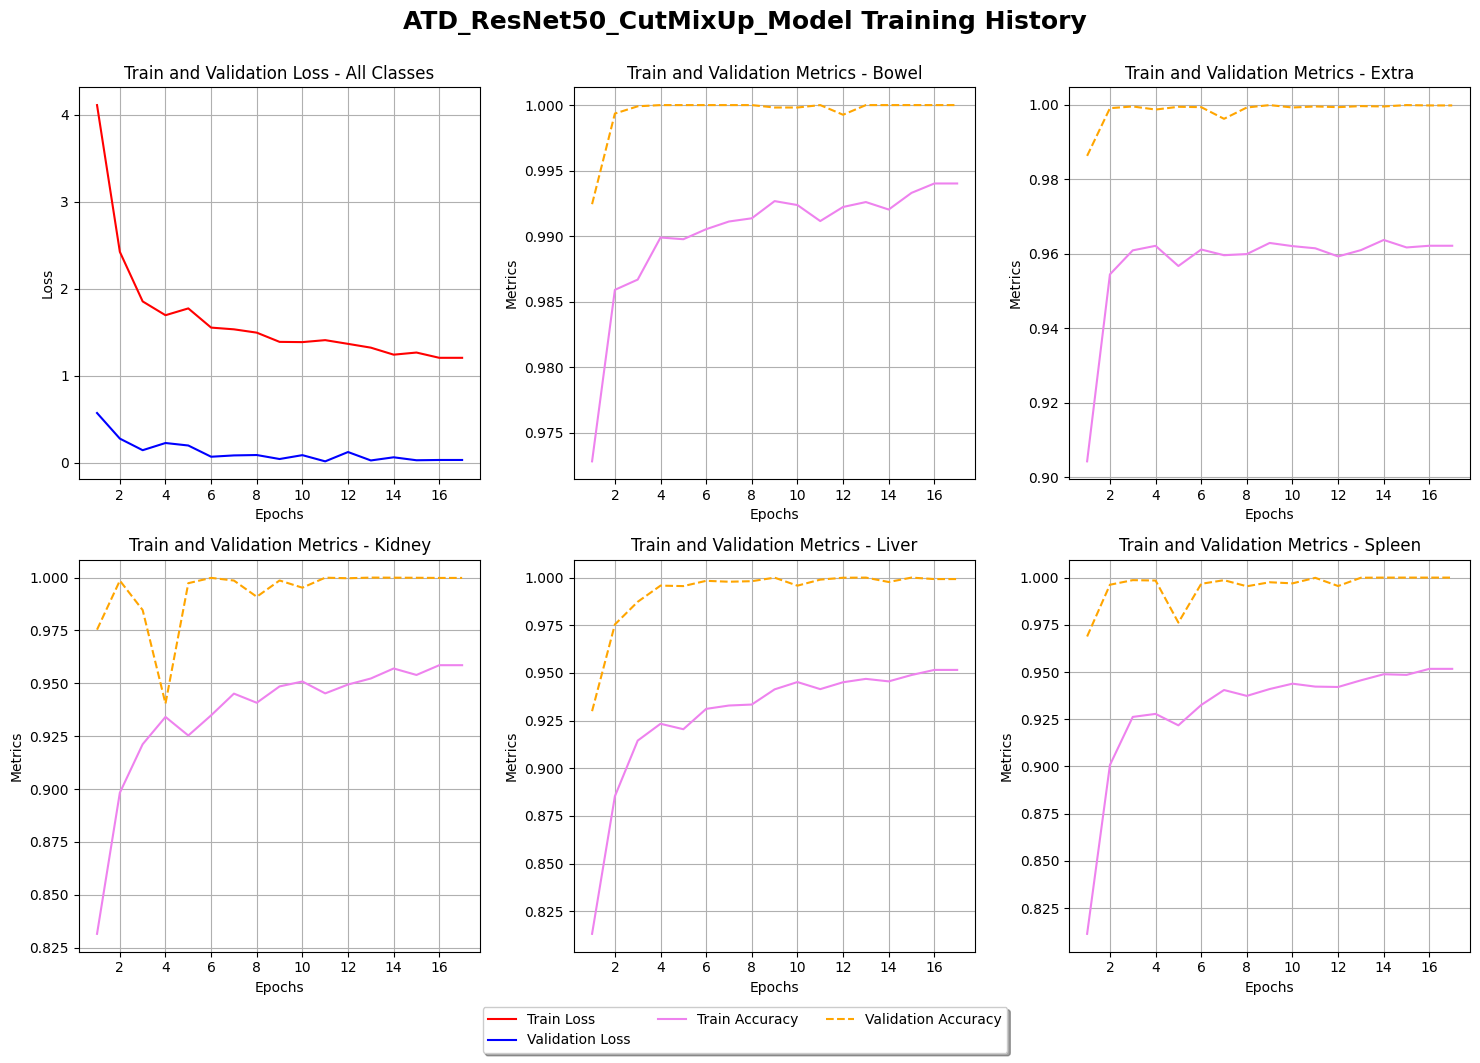

In [ ]:
from torch_helper_functions import plotting_utils
plotting_utils.plot_model_history_curves(ATD_ResNet50_CutMixUp_Model_history)

## Step 12: Evaluating Trained Model On Test Data

In [ ]:
from torch_helper_functions import utils
utils.model_evaluation(ATD_ResNet50_CutMixUp_Model,
                      dataloader=test_dataloader,
                      criterion_bowel=criterion_bowel,
                      criterion_extra=criterion_extra,
                      criterion_kidney=criterion_kidney,
                      criterion_liver=criterion_liver,
                      criterion_spleen=criterion_spleen)

Testing:   0%|          | 0/399 [00:00<?, ?it/s]

Test loss is: 0.0292
╒═══════════╤══════════╤═══════════════╤══════════╤══════════╤══════════╕
│ Results   │    bowel │   extravation │   kidney │    liver │   spleen │
╞═══════════╪══════════╪═══════════════╪══════════╪══════════╪══════════╡
│ Accuracy  │ 1        │      0.999765 │ 0.99996  │ 0.998361 │        1 │
├───────────┼──────────┼───────────────┼──────────┼──────────┼──────────┤
│ F1_Score  │ 0.365915 │      0.986735 │ 0.999562 │ 0.997214 │        1 │
╘═══════════╧══════════╧═══════════════╧══════════╧══════════╧══════════╛ 



## Step 13: Plotting Confusion Matrix For All Labels

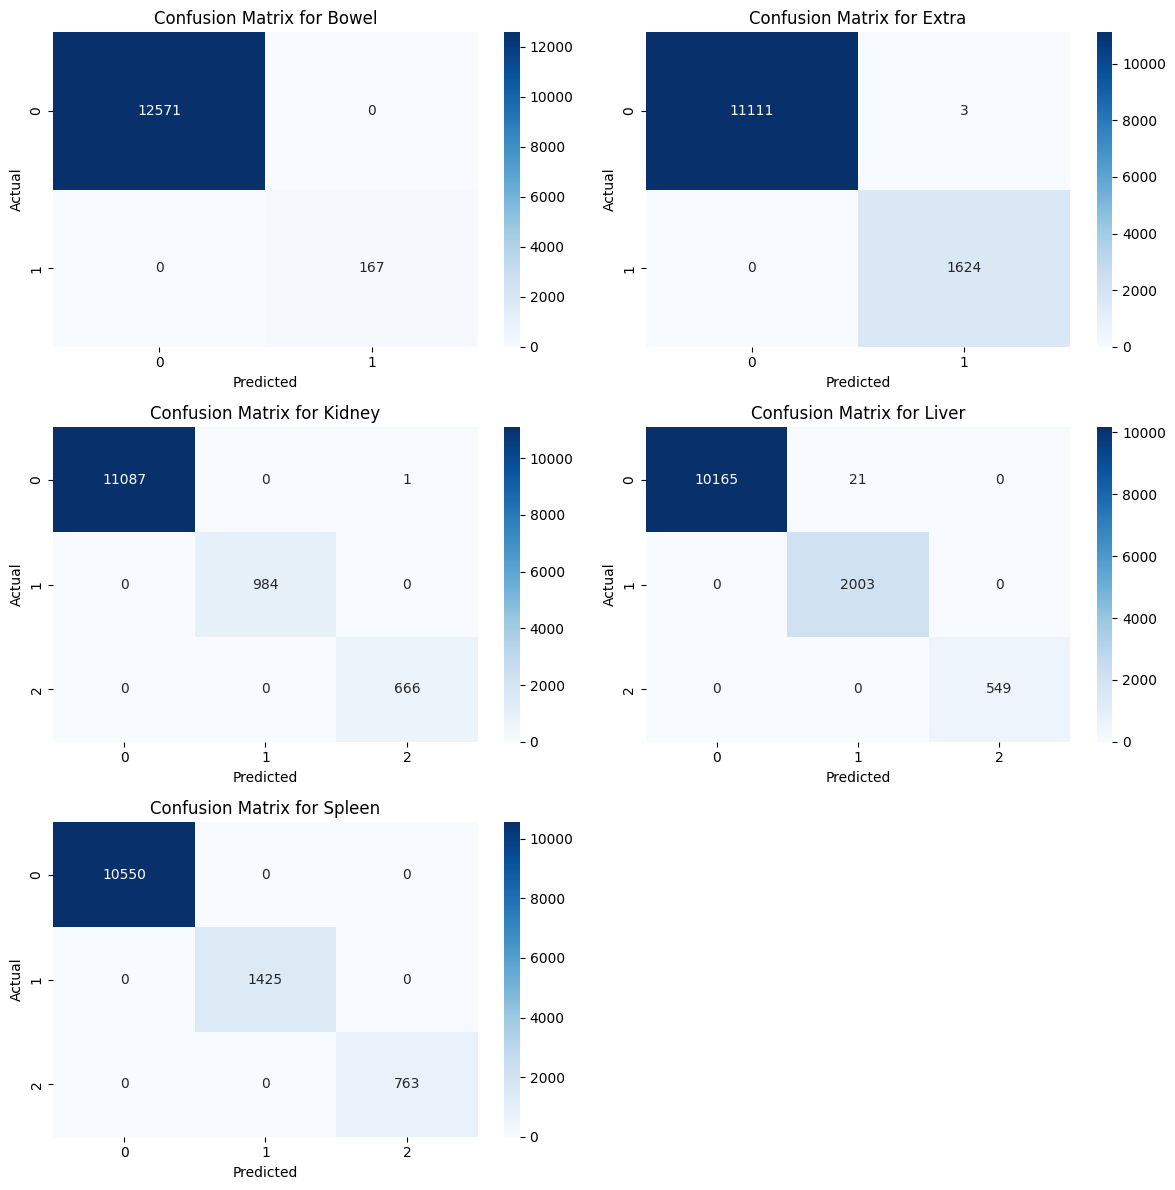

In [ ]:
from torch_helper_functions import plotting_utils
plotting_utils.generate_confusion_matrix(ATD_ResNet50_CutMixUp_Model, test_dataloader)

## Step 14: Predicting Image Data With Our Model

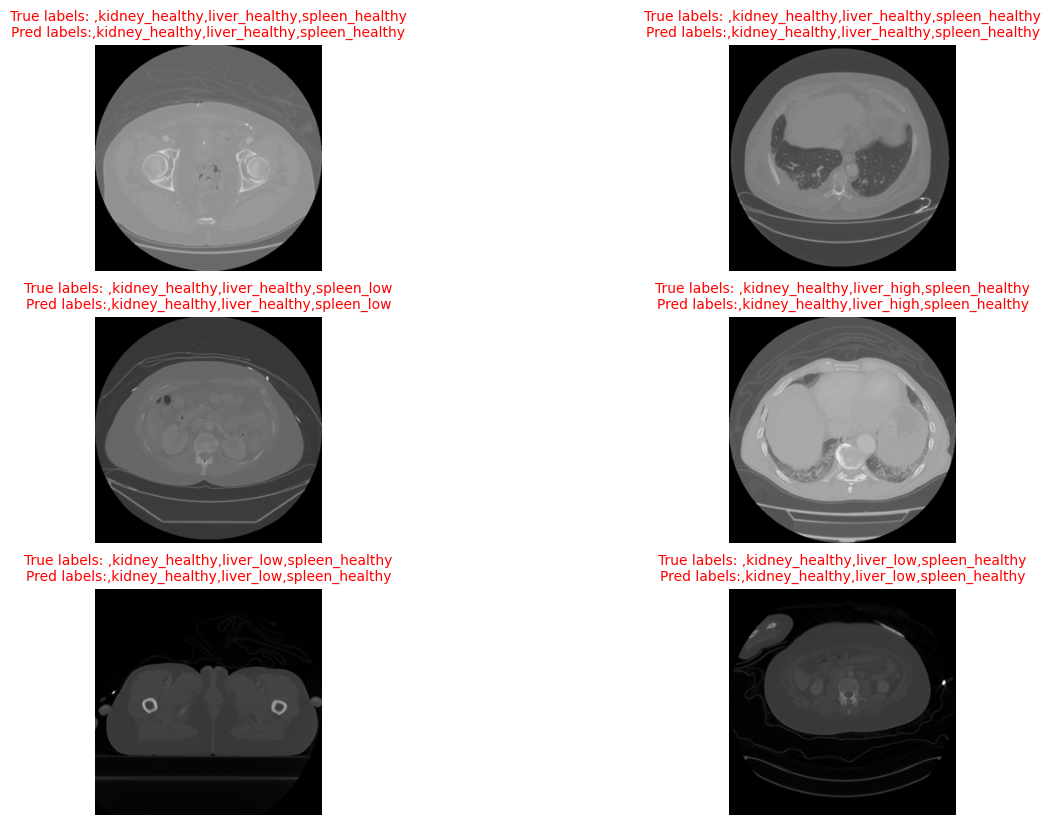

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
ATD_ResNet50_CutMixUp_Model.eval()
# Visualizing labels and images
images,y_bowel, y_extra, y_kidney, y_liver, y_spleen = next(iter(test_dataloader))
# Forward pass
with torch.inference_mode():
  bowel_out, extra_out, kidney_out, liver_out, spleen_out = ATD_ResNet50_CutMixUp_Model(images.to(device))

# Convert logits to predictions
bowel_preds = (torch.sigmoid(bowel_out) > 0.5).int().cpu().numpy().flatten()
extra_preds = (torch.sigmoid(extra_out) > 0.5).int().cpu().numpy().flatten()
kidney_preds = np.argmax(F.softmax(kidney_out, dim=1).cpu().numpy(), axis=1).flatten()
liver_preds = np.argmax(F.softmax(liver_out, dim=1).cpu().numpy(), axis=1).flatten()
spleen_preds = np.argmax(F.softmax(spleen_out, dim=1).cpu().numpy(), axis=1).flatten()
# Display sample data and labels
fig,ax = plt.subplots(3,2,figsize=(15,10))
ax = ax.ravel()
for k in range(6):
  label=''
  pred_label=''
  i = random.choice(range(0,31))
  ax[k].imshow(images[i].permute(1,2,0),cmap="gray")
  if y_bowel[i].item()==1:
    label+=","+label_columns[0]
  if y_extra[i].item()==1:
    label+=","+label_columns[1]
  label+=","+label_columns[2+y_kidney[i].argmax()]
  label+=","+label_columns[5+y_liver[i].argmax()]
  label+=","+label_columns[8+y_spleen[i].argmax()]

  if bowel_preds[i].item()==1:
    pred_label+=","+label_columns[0]
  if extra_preds[i].item()==1:
    pred_label+=","+label_columns[1]
  pred_label+=","+label_columns[2+kidney_preds[i]]
  pred_label+=","+label_columns[5+liver_preds[i]]
  pred_label+=","+label_columns[8+spleen_preds[i]]
  ax[k].set_title(f"True labels: {label}\nPred labels:{pred_label}",fontsize=10,color="r")
  ax[k].axis("off")